Utilize o dataset Customers.csv e crie clusters desses mesmos clientes usando K-Means



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('../dataset/Customers.csv')
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
190,191,Female,34,103,23
16,17,Female,35,21,35
193,194,Female,38,113,91
70,71,Male,70,49,55
180,181,Female,37,97,32


In [3]:
df.describe()
# mostra os dados estatisticos do dataset 

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.info()
# mostra o tipo de dados de cada coluna


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()
# mostra a quantidade de valores nulos em cada coluna

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

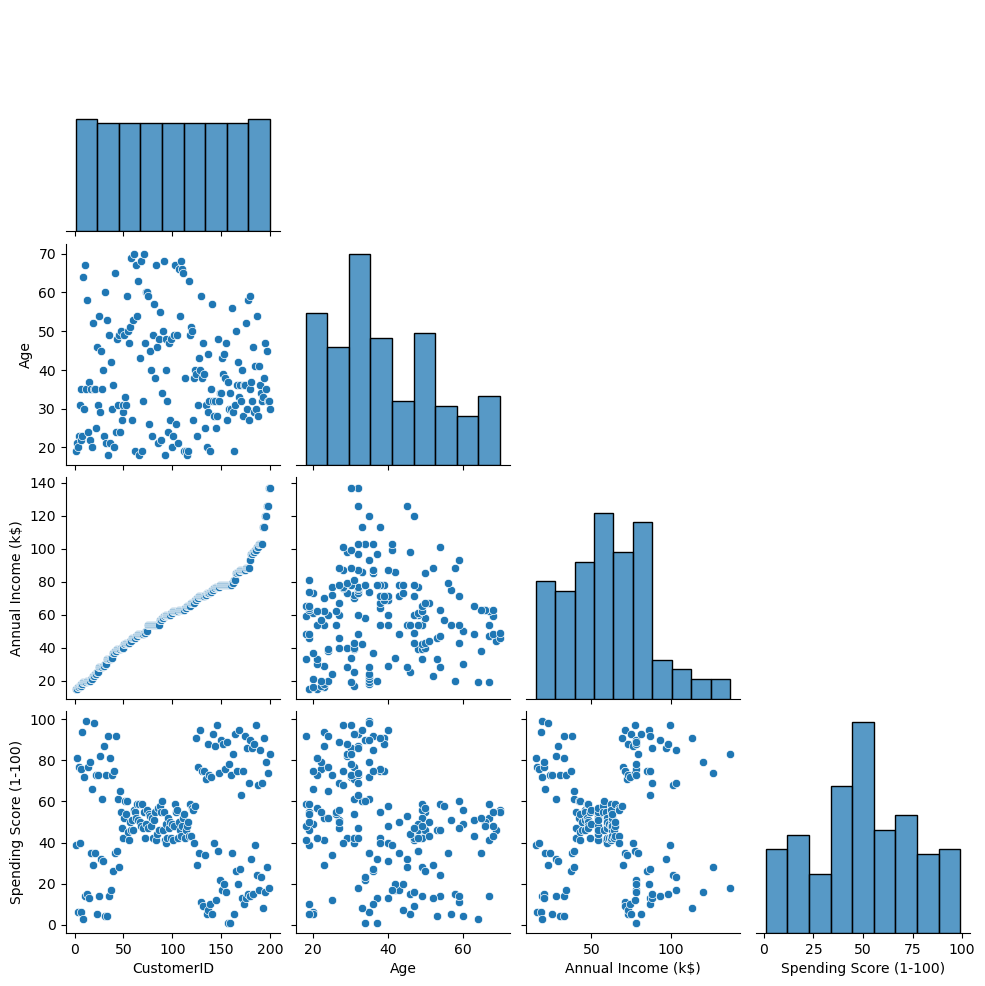

In [6]:
# Pairplot apenas com colunas numéricas para evitar erros com categóricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sns.pairplot(df[num_cols], corner=True)
plt.show()
# comentários: isso mostra relações entre variáveis numéricas (distribuições e correlações visuais)

Pré-Processamento

In [7]:
# Pré-processamento: remover identificadores e codificar 'Gender'
df = df.copy()
if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

from sklearn.preprocessing import OneHotEncoder
# OneHotEncoder tem parâmetro diferente entre versões do sklearn; usar try/except
try:
    encoder = OneHotEncoder(sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(sparse=False)

if 'Gender' in df.columns:
    encoded_cols = encoder.fit_transform(df[['Gender']])
    feature_names = encoder.get_feature_names_out(['Gender'])
    encoded_df = pd.DataFrame(encoded_cols, columns=feature_names, index=df.index)
    df = pd.concat([df.drop(columns=['Gender']), encoded_df], axis=1)



In [8]:
# Escalonamento: selecionar features relevantes e escalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Definir features que serão usadas no clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
# incluir colunas de gender codificadas, se existirem
for c in df.columns:
    if c.startswith('Gender_') and c not in features:
        features.append(c)

X_df = df[features].dropna().copy()  # remover linhas com NA nessas features
X = X_df.values
X_scaled = scaler.fit_transform(X)
print('Forma X_scaled:', X_scaled.shape)
# guardamos X_df e X_scaled para uso posterior
_X_df = X_df
_X_scaled = X_scaled

Forma X_scaled: (200, 5)


c:\Users\Miguel Caldas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Miguel Caldas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Miguel Caldas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Miguel Caldas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

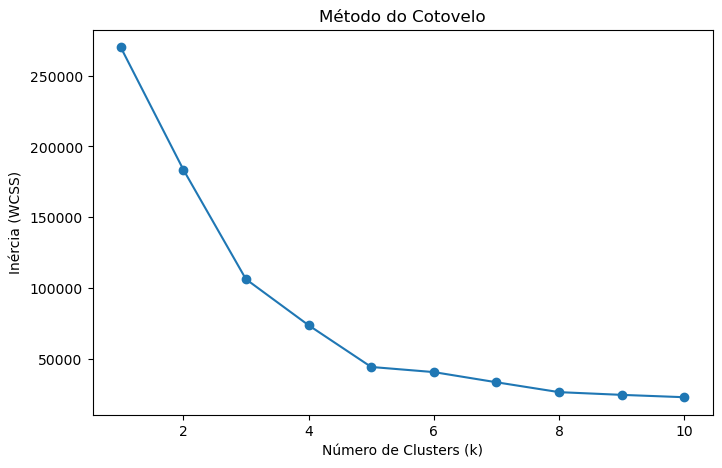

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (WCSS)')
plt.show()

In [10]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

k_ideal = 5
kmeans = KMeans(n_clusters=k_ideal, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df

c:\Users\Miguel Caldas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,cluster
0,19,15,39,0.0,1.0,4
1,21,15,81,0.0,1.0,2
2,20,16,6,1.0,0.0,4
3,23,16,77,1.0,0.0,2
4,31,17,40,1.0,0.0,4
...,...,...,...,...,...,...
195,35,120,79,1.0,0.0,1
196,45,126,28,1.0,0.0,3
197,32,126,74,0.0,1.0,1
198,32,137,18,0.0,1.0,3


In [11]:
# resultado do kmeans


plt.figure(figsize=(8, 5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.scatter(kmeans.clustercenters[:, 0], kmeans.clustercenters[:, 1], s=200, c='red', marker='X', label='Centróides')
plt.title(f"Clustering Final (k={k_ideal})")
plt.legend()
plt.show()

KeyError: 'Cluster'

<Figure size 800x500 with 0 Axes>